In [1]:
import matplotlib.pyplot as plt
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from dotenv import load_dotenv
from src.constants import STATE_CONFIG
from src.datasources import glofas

load_dotenv()

STATE = "Adamawa"
cfg = STATE_CONFIG[STATE]
FIGURES_DIR = "figures"

ANALYSIS_START_YEAR = cfg["analysis_start_year"]
ANALYSIS_END_YEAR = cfg["analysis_end_year"]
WET_MONTHS = [8, 9, 10, 11]
RP_LEVELS = [3, 5]
MAX_LEADTIME = 16
RP_COLORS = {3: "#74ADD1", 5: "#D73027"}

/Users/hannahker/Desktop/AA/ds-aa-nga-flooding/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

In [2]:
# GloFAS reforecast ensemble
df_gf_rf = stratus.load_parquet_from_blob(cfg["glofas_reforecast_blob"])
df_gf_rf["time"] = pd.to_datetime(df_gf_rf["time"])
df_gf_rf["valid_time"] = pd.to_datetime(df_gf_rf["valid_time"])
df_gf_rf = df_gf_rf[df_gf_rf["leadtime"] <= MAX_LEADTIME]

## Floodscan return period thresholds

Flood year classifications are loaded from the trigger matrix produced by `08_trigger_events.ipynb`,
which computes annual max SFED across all months (no wet-season filter) for consistency with the
2025 analysis. This is the canonical source of truth for flood years across all notebooks.

Performance evaluation is restricted to years where GloFAS reforecast data exists (2003–2022).

The 4-year RP level is excluded because the Floodscan years that distinguish it from the 5-year
RP level all fall outside the GloFAS reforecast window, making the two event sets identical within
the evaluation period.

In [3]:
trigger_matrix_blob = f"ds-aa-nga-flooding/processed/trigger_matrix/{STATE.lower()}_trigger_matrix.parquet"
df_trig = stratus.load_parquet_from_blob(trigger_matrix_blob)

all_fs_years = set(df_trig["year"])
fs_event_years = {
    rp: set(df_trig[df_trig[f"fs_{rp}yr"] == 1]["year"])
    for rp in RP_LEVELS
}

for rp in RP_LEVELS:
    print(f"Floodscan {rp}-year RP event years: {sorted(fs_event_years[rp])}")

Floodscan 3-year RP event years: [1998, 1999, 2003, 2012, 2015, 2018, 2019, 2022, 2023]
Floodscan 5-year RP event years: [1999, 2012, 2015, 2022, 2023]


## GloFAS reforecast preparation

Ensemble mean discharge per (valid_time, leadtime). Cumulative max is computed within each year
across leadtimes: at leadtime lt, `cum_max` is the highest ensemble-mean forecast seen at any
leadtime \u2264 lt during the wet season. A year is activated if `cum_max` exceeds the trigger
threshold (`glofas_thresh` from STATE_CONFIG).

In [4]:
df_gf_rf_mean = (
    df_gf_rf.groupby(["valid_time", "leadtime"])["dis24"]
    .mean()
    .reset_index()
)

rf_wet = df_gf_rf_mean[
    df_gf_rf_mean["valid_time"].dt.month.isin(WET_MONTHS)
    & df_gf_rf_mean["valid_time"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
].copy()
rf_wet["year"] = rf_wet["valid_time"].dt.year

rf_annual = (
    rf_wet.groupby(["year", "leadtime"])["dis24"].max()
    .reset_index()
    .sort_values(["year", "leadtime"])
)
rf_annual["cum_max"] = rf_annual.groupby("year")["dis24"].cummax()

years_in_rf = sorted(rf_annual["year"].unique())
print(f"GloFAS reforecast: {years_in_rf[0]}\u2013{years_in_rf[-1]} ({len(years_in_rf)} years)")
print(f"Leadtime range   : {int(rf_annual['leadtime'].min())}\u2013{int(rf_annual['leadtime'].max())} days")
print(f"Trigger threshold: {cfg['glofas_thresh']:,} m\u00b3/s")

GloFAS reforecast: 2003–2022 (20 years)
Leadtime range   : 1–16 days
Trigger threshold: 3,132 m³/s


## Performance evaluation

For each (leadtime, RP level), years where GloFAS reforecast exists are classified into:

- **TP**: GloFAS activated AND Floodscan event year
- **FP**: GloFAS activated AND NOT Floodscan event year (false alarm)
- **FN**: GloFAS did NOT activate AND Floodscan event year (miss)
- **TN**: GloFAS did NOT activate AND NOT Floodscan event year

Metrics:

| Metric | Formula |
|---|---|
| Accuracy | (TP + TN) / N |
| Detection rate (POD) | TP / (TP + FN) |
| False alarm ratio (FAR) | FP / (TP + FP) |
| Precision | TP / (TP + FP) |
| F1 score | 2 \u00d7 Precision \u00d7 POD / (Precision + POD) |

Note: FAR and Precision are complementary (FAR + Precision = 1) \u2014 FAR answers \u201cof all activations,
how many were wrong?\u201d while Precision answers \u201chow many were right?\u201d

In [5]:
def trigger_performance(rf_annual, all_fs_years, fs_event_years, rp_levels, thresh):
    """Accuracy, detection rate, FAR, precision, and F1 vs leadtime for each RP level.

    Truth: Floodscan flood years from trigger matrix (notebook 08, all-months annual max).
    Trigger: GloFAS cumulative max reforecast at leadtime <= lt >= thresh (once per year).
    """
    results = {}
    for rp in rp_levels:
        records = []
        for lt, grp in rf_annual.groupby("leadtime"):
            merged = grp.set_index("year")[["cum_max"]]
            merged = merged[merged.index.isin(all_fs_years)].copy()
            merged["event"] = merged.index.isin(fs_event_years[rp]).astype(int)
            merged["trigger"] = (merged["cum_max"] > thresh).astype(int)

            tp = int(((merged["trigger"] == 1) & (merged["event"] == 1)).sum())
            fp = int(((merged["trigger"] == 1) & (merged["event"] == 0)).sum())
            fn = int(((merged["trigger"] == 0) & (merged["event"] == 1)).sum())
            tn = int(((merged["trigger"] == 0) & (merged["event"] == 0)).sum())
            n = tp + fp + fn + tn

            accuracy = (tp + tn) / n if n > 0 else np.nan
            detection_rate = tp / (tp + fn) if (tp + fn) > 0 else np.nan
            far = fp / (tp + fp) if (tp + fp) > 0 else np.nan
            precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
            f1_denom = (precision or 0) + (detection_rate or 0)
            f1 = (2 * precision * detection_rate / f1_denom
                  if (precision is not None and detection_rate is not None and f1_denom > 0)
                  else np.nan)

            records.append({
                "leadtime": lt,
                "accuracy": accuracy,
                "detection_rate": detection_rate,
                "far": far,
                "precision": precision,
                "f1": f1,
                "tp": tp, "fp": fp, "fn": fn, "tn": tn, "n": n,
            })
        results[rp] = pd.DataFrame(records).set_index("leadtime")
    return results


perf = trigger_performance(rf_annual, all_fs_years, fs_event_years, RP_LEVELS, thresh=cfg["glofas_thresh"])

for rp in RP_LEVELS:
    n_events = len(fs_event_years[rp] & set(years_in_rf))
    print(f"\n--- {rp}-year RP  ({n_events} event years within GloFAS period) ---")
    print(perf[rp][["accuracy", "detection_rate", "far", "precision", "f1",
                     "tp", "fp", "fn", "tn"]].round(2).to_string())


--- 3-year RP  (6 event years within GloFAS period) ---
          accuracy  detection_rate   far  precision    f1  tp  fp  fn  tn
leadtime                                                                 
1             0.80            0.33  0.00       1.00  0.50   2   0   4  14
2             0.80            0.33  0.00       1.00  0.50   2   0   4  14
3             0.80            0.33  0.00       1.00  0.50   2   0   4  14
4             0.80            0.33  0.00       1.00  0.50   2   0   4  14
5             0.80            0.33  0.00       1.00  0.50   2   0   4  14
6             0.75            0.33  0.33       0.67  0.44   2   1   4  13
7             0.70            0.33  0.50       0.50  0.40   2   2   4  12
8             0.75            0.50  0.40       0.60  0.55   3   2   3  12
9             0.75            0.50  0.40       0.60  0.55   3   2   3  12
10            0.75            0.50  0.40       0.60  0.55   3   2   3  12
11            0.80            0.67  0.33       0.67  0.

## Performance plots

Each line shows how a metric varies across leadtime for a given Floodscan RP event definition.
The shaded region indicates the current GloFAS action leadtime window (\u2264 5 days for Adamawa).

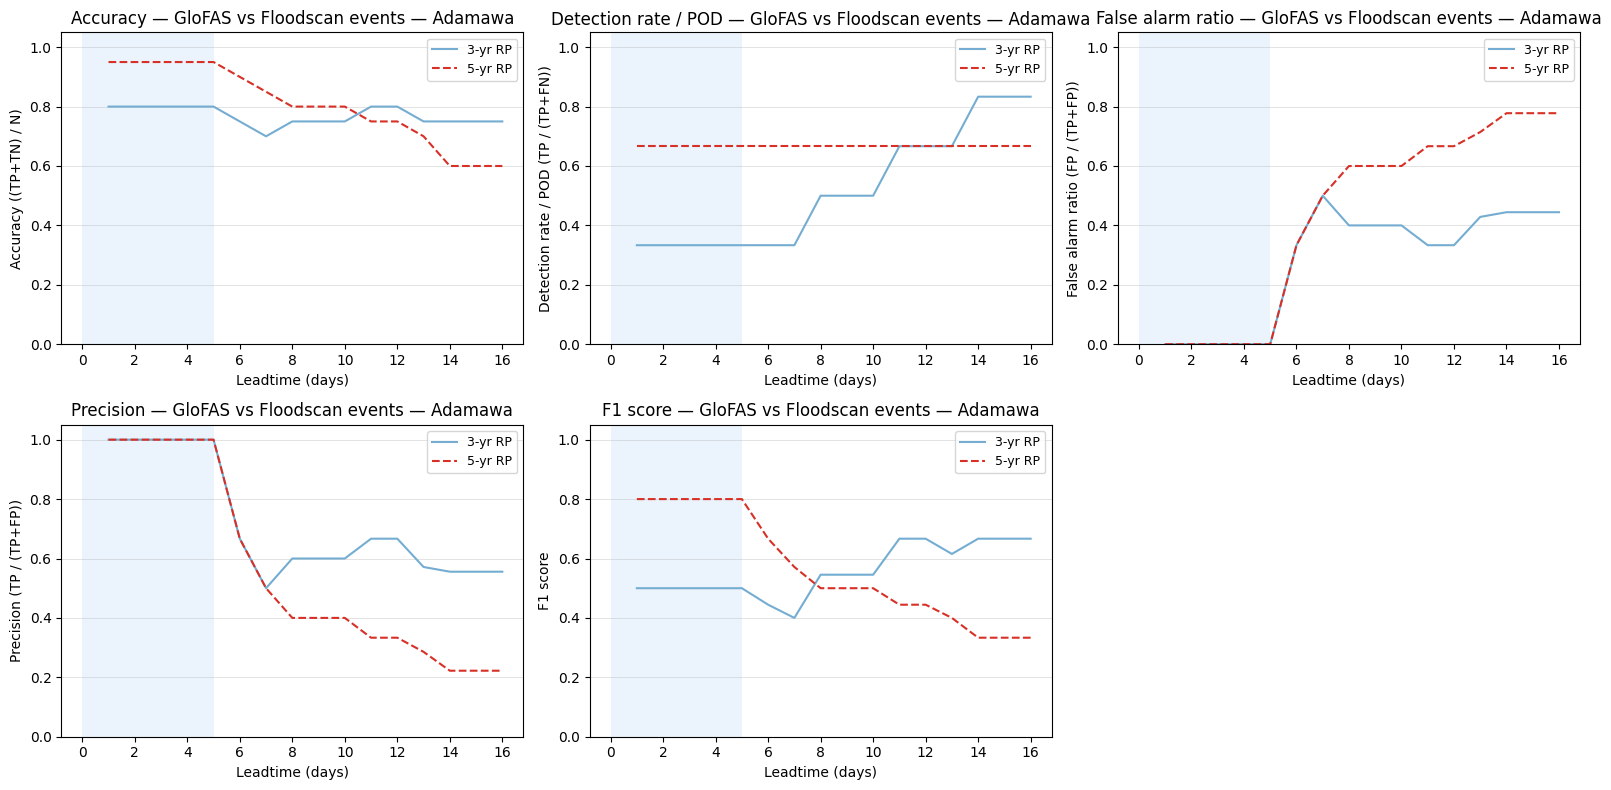

In [6]:
action_lt = cfg.get("glofas_leadtime_action")

RP_LINESTYLES = {3: "-", 5: "--"}

metrics = [
    ("accuracy",       "Accuracy ((TP+TN) / N)"),
    ("detection_rate", "Detection rate / POD (TP / (TP+FN))"),
    ("far",            "False alarm ratio (FP / (TP+FP))"),
    ("precision",      "Precision (TP / (TP+FP))"),
    ("f1",             "F1 score"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes_flat = axes.flatten()

for i, (metric, ylabel) in enumerate(metrics):
    ax = axes_flat[i]
    if action_lt is not None:
        ax.axvspan(0, action_lt, facecolor="#007CE0", edgecolor="none", alpha=0.08, zorder=0)
    for rp in RP_LEVELS:
        df = perf[rp]
        if not df.empty and metric in df.columns:
            ax.plot(
                df.index, df[metric],
                color=RP_COLORS[rp],
                linestyle=RP_LINESTYLES[rp],
                label=f"{rp}-yr RP",
            )
    ax.set_xlabel("Leadtime (days)")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{ylabel.split(' (')[0]} — GloFAS vs Floodscan events — {STATE}")
    ax.legend(fontsize=9)
    ax.grid(axis="y", linewidth=0.5, alpha=0.5)

axes_flat[5].set_visible(False)

plt.tight_layout()
plt.savefig(
    f"{FIGURES_DIR}/{STATE.lower()}_trigger_performance_vs_floodscan.png",
    dpi=200, bbox_inches="tight",
)
plt.show()